In [12]:
%load_ext autoreload
%autoreload 2

from utils import make_spikes_responses_df
import os 
import numpy as np
import pandas as pd
import yaml
import shutil
from utils import read_pattern_json, preprocess_pattern_stimulations_df

# =====================
# Load Configuration
# =====================
CONFIG_PATH = "config.yaml"  # Change this to use a different config file

with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

# Extract data settings from config
datadir = cfg['datadir']
problematic_neurons = cfg['problematic_neurons']

spikes_df = make_spikes_responses_df(os.path.join(datadir, "spkVecs.npy"))
spikes_df.head(5)

# optionally, drop neurons with very high firing rates that may be multi-unit activity or artifacts
spikes_df = spikes_df[~spikes_df['neuron_id'].isin(problematic_neurons)]
print (spikes_df['neuron_id'].nunique(), " unique neurons recorded after dropping problematic neurons")
pattern_registrations_path = os.path.join(datadir, "pattern_registrations.pkl")
pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json(pattern_registrations_path), align_to_stim=True)
spikes_df['timestamp']
pattern_df.head(30)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
63  unique neurons recorded after dropping problematic neurons


,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial,pattern_end_timestamp,pattern_flag_start_timestamp,pattern_duration
0,0,902542,4033,1.0,0,10,81.0,-1.0,True,1,964150,902542,61608
1,0,902542,4033,1.0,0,10,89.0,0.0,True,1,964150,902542,61608
2,1,904573,4033,1.0,0,10,7.0,2.0,True,1,964150,902542,61608
3,1,904573,4033,1.0,0,10,4.0,0.0,True,1,964150,902542,61608
4,1,904573,4033,1.0,0,10,34.0,0.0,True,1,964150,902542,61608
5,2,906473,4033,1.0,0,10,3.0,-1.0,True,1,964150,902542,61608
6,2,906473,4033,1.0,0,10,4.0,0.0,True,1,964150,902542,61608
7,3,908405,4033,1.0,0,10,63.0,-1.0,True,1,964150,902542,61608
8,3,908405,4033,1.0,0,10,70.0,0.0,True,1,964150,902542,61608
9,4,910364,4033,1.0,0,10,14.0,1.0,True,1,964150,902542,61608


In [13]:
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = spikes_df['neuron_id'].unique()
spiking_neuron_to_index = {neuron: idx for idx, neuron in enumerate(spiking_neurons)}
spiking_neurons.sort()

print (f"Total unique stimulation channels used: {len(channel_to_index)}")
print ("Stimulation channel names: ", [str(int(k)) for k in sorted(channel_to_index.keys())])

print (f"Total spiking neurons recorded: {len(spiking_neurons)}")
print ("Spiking neuron names: ", spiking_neurons)


Total unique stimulation channels used: 42
Stimulation channel names:  ['1', '2', '3', '4', '7', '9', '10', '12', '14', '20', '22', '30', '33', '34', '36', '37', '39', '41', '44', '46', '47', '49', '54', '56', '60', '63', '64', '66', '67', '69', '70', '71', '72', '73', '81', '82', '88', '89', '90', '92', '93', '95']
Total spiking neurons recorded: 63
Spiking neuron names:  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  20  21  22  23 100 101 102 103 105 106 107 108 109 110 111 200 202
 203 204 205 206 207 208 209 210 212 213 214 301 302 303 304 305 306 307
 308 309 313 314 315 316 317 318 319]


In [14]:
from utils import trial_breakout_spikes_and_patterns

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = trial_breakout_spikes_and_patterns(
    spikes_df,
    pattern_df,
    channel_to_index,
    spiking_neurons=spiking_neurons,
    spiking_neuron_to_index=spiking_neuron_to_index,
    
)

# Note pattern stims and polarities are keyed by pattern_name while spike_responses and timing_to_pattern are keyed by timing index. timing_to_pattern connects timing index to pattern name in case you need it.
# spikes are recorded in 1 ms resolution in this spikes_responses

print(f"Total unique patterns: {len(pattern_stims)}")
print(f"Total trials (spike responses): {len(spike_responses)}")
print(f"Oracle trials: {unique_trials['is_oracle'].sum()}")
print(f"Non-oracle trials: {(~unique_trials['is_oracle']).sum()}")



Total unique patterns: 4050
Total trials (spike responses): 5000
Oracle trials: 1000
Non-oracle trials: 4000


In [16]:
# Example: Plot stimulation pattern for a specific pattern (colored by polarity)
# from viz import plot_oracle_pattern_average_responses, plot_stimulation_polarity_timeseries
# oracle_trials = unique_trials[unique_trials['is_oracle']]['pattern_name'].unique()
# for pattern in pattern_df['pattern_name'].unique():
#     pattern_name = (int(pattern))
#     if pattern_name in oracle_trials:
#         plot_stimulation_polarity_timeseries(pattern_stims, pattern_polarities, pattern_name=pattern_name, savepath=os.path.join(datadir, 'stim_viz/oracle/'))
#     plot_stimulation_polarity_timeseries(pattern_stims, pattern_polarities, pattern_name=pattern_name, savepath=os.path.join(datadir, 'stim_viz/'))

# plot_oracle_pattern_average_responses(unique_trials, spike_responses, spiking_neurons, savepath=os.path.join(datadir, 'oracle_pattern_averages_bin_fixed/'), plot_duration=600, bin_size=60)

In [17]:
# Plot ticks for spike_responses[0]
from utils import bin_spike_response
import matplotlib.pyplot as plt
idxs = pattern_df[pattern_df["is_oracle"]]["pattern_timing_index"].unique()
total_time = 600
for idx in idxs: 
    f, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(10, 6), constrained_layout=True)

    # raster: time indices are in ms (columns)
    neuron_indices, time_indices = np.where(spike_responses[idx][:, :total_time] > 0) # remember, spike_responses is in 1 ms resolution (2000 bins max)

    # s=20 controls marker size, marker='|' gives the classic look
    ax[0].scatter(time_indices, neuron_indices, s=20, c='black', marker='|', linewidths=0.8)
    ax[0].set_ylabel('Neuron ID')
    ax[0].set_title('Spike Raster Plot')

    # Determine total time in ms from the 1ms-resolution array
    ax[0].set_xlim(0, total_time)
    ax[0].set_xlabel('Time (ms)')

    # Binned heatmap: ensure the image extent maps columns to the same ms range
    binned = bin_spike_response(spike_responses[idx], bin_size=60, max_time=total_time)
    # binned shape: (n_neurons, n_bins)
    n_neurons_binned, n_bins = binned.shape
    # extent: [x0, x1, y0, y1] where x is time in ms and y is neuron index space
    extent = [0, total_time, n_neurons_binned, 0]
    im = ax[1].imshow(binned, aspect='auto', interpolation='nearest', extent=extent, cmap='viridis')
    ax[1].set_xlabel('Time (ms)')
    ax[1].set_ylabel('Neuron ID')
    ax[1].set_title(f'Binned spike counts ({60} ms bins)')
    ax[1].set_xlim(0, total_time)

    plt.colorbar(im, ax=ax[1], label='Spike count')

    # Other trials
    relevant_pattern = pattern_df[pattern_df["pattern_timing_index"] == idx].loc[:, ["pattern_name", "is_oracle", "trial"]].drop_duplicates()
    this_pattern_name = relevant_pattern["pattern_name"].iloc[0]
    this_pattern_trial = relevant_pattern["trial"].iloc[0]
    avg = np.zeros_like(binned)
    print (relevant_pattern)
    if relevant_pattern['is_oracle'].iloc[0]:
        other_patterns = pattern_df[(pattern_df["pattern_name"] == this_pattern_name) & (pattern_df["trial"] != this_pattern_trial)]
        other_trials = other_patterns["trial"].unique()
        for trial in other_trials: 
            other_trial_data = other_patterns[other_patterns["trial"] == trial]
            other_trial_idx = other_trial_data["pattern_timing_index"].unique()
            assert other_trial_idx.shape[0] == 1
            other_trial_idx = other_trial_idx[0]
            binned_other_trial = bin_spike_response(spike_responses[other_trial_idx], bin_size=60, max_time=total_time)
            avg += binned_other_trial
    avg /= len(other_trials)
    print (np.amax(avg))
    im1 = ax[2].imshow(avg, aspect="auto", interpolation="nearest", extent=extent, cmap='viridis')
    ax[2].set_xlabel('Time (ms)')
    ax[2].set_ylabel('Neuron ID')
    ax[2].set_title(f'Binned spike counts ({60} ms bins average over {len(other_trials)} trials)')
    ax[2].set_xlim(0, total_time)
    plt.colorbar(im1, ax=ax[2], label="Spike count")
    if not os.path.exists(os.path.join(datadir, "oracle_trial_averages")):
        os.makedirs(os.path.join(datadir, "oracle_trial_averages"))
    plt.savefig(os.path.join(datadir, "oracle_trial_averages", f"{this_pattern_name}_{this_pattern_trial}.png"))
    plt.close()

  pattern_name  is_oracle  trial
0         4033       True      1
3.3157895
   pattern_name  is_oracle  trial
21         4017       True      1
3.5789473
   pattern_name  is_oracle  trial
43         4028       True      1
4.3157897
   pattern_name  is_oracle  trial
89         4003       True      1
3.7894738
    pattern_name  is_oracle  trial
214         4025       True      1
2.8421052
    pattern_name  is_oracle  trial
402         4004       True      1
3.5263157
    pattern_name  is_oracle  trial
847         4040       True      1
5.736842
     pattern_name  is_oracle  trial
1253         4038       True      1
3.3157895
     pattern_name  is_oracle  trial
1377         4022       True      1
4.3157897
     pattern_name  is_oracle  trial
1640         4034       True      1
2.7368422
     pattern_name  is_oracle  trial
1701         4030       True      1
7.2105265
     pattern_name  is_oracle  trial
1729         4031       True      1
3.7368422
     pattern_name  is_oracle  trial
1796 

Total unique oracle patterns: 50
Oracle pattern: 4033
Timing indices for pattern 4033: [0, 355, 457, 638, 1132, 1179, 1800, 2745, 2789, 2813, 3230, 3262, 3661, 3727, 3760, 3930, 4023, 4056, 4064, 4701]
New max average spike rate found: 1.3 for pattern 4033


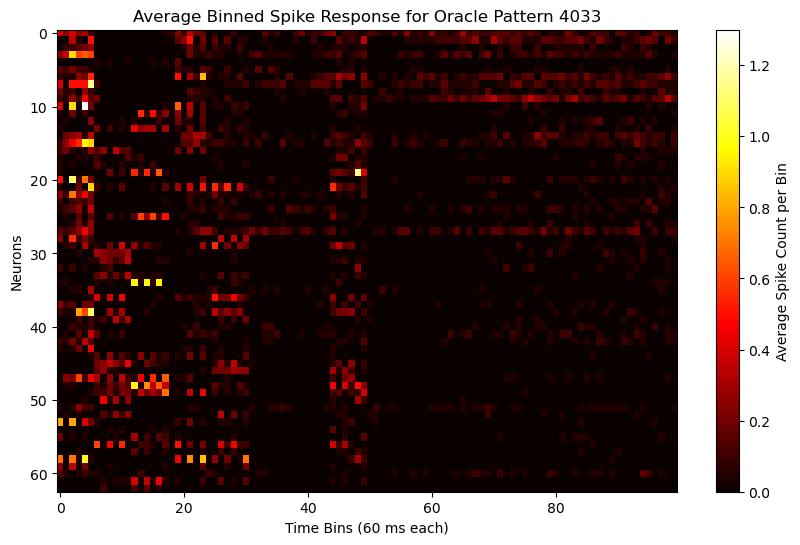

Oracle pattern: 4017
Timing indices for pattern 4017: [1, 114, 270, 313, 1322, 1418, 1609, 2331, 2594, 2890, 3058, 3154, 3288, 3436, 3717, 4086, 4265, 4495, 4630, 4898]
Oracle pattern: 4028
Timing indices for pattern 4028: [2, 97, 122, 305, 802, 1556, 1584, 1676, 1913, 1930, 1978, 2422, 2688, 2735, 2833, 2896, 3108, 3678, 4704, 4782]
New max average spike rate found: 1.5 for pattern 4028
Oracle pattern: 4003
Timing indices for pattern 4003: [4, 168, 220, 441, 513, 1470, 1522, 1616, 1811, 1918, 2204, 2452, 2603, 2763, 2915, 3359, 4043, 4122, 4384, 4640]
Oracle pattern: 4025
Timing indices for pattern 4025: [9, 549, 1664, 1710, 2305, 2718, 2843, 2894, 2919, 2977, 3043, 3182, 3310, 3447, 3467, 3908, 4402, 4451, 4754, 4990]
Oracle pattern: 4004
Timing indices for pattern 4004: [18, 665, 742, 1117, 1169, 1400, 1585, 2222, 2499, 2599, 2701, 2865, 2885, 3257, 3358, 3763, 4010, 4091, 4673, 4739]
Oracle pattern: 4040
Timing indices for pattern 4040: [38, 813, 977, 1065, 1408, 1456, 2172, 2464, 

In [18]:
# find timing_idx for a given pattern_name
from utils import bin_spike_response
import matplotlib.pyplot as plt 

max_avg = -np.inf
oracle_patterns = unique_trials[unique_trials['is_oracle']]['pattern_name'].unique()
print (f"Total unique oracle patterns: {len(oracle_patterns)}")
for oracle in oracle_patterns:     
    if oracle == 4033:
        show_a = True
    else:
        show_a = False
    print (f"Oracle pattern: {oracle}")
    timing_indices = unique_trials[unique_trials['pattern_name'] == oracle]['pattern_timing_index'].tolist()
    print (f"Timing indices for pattern {oracle}: {timing_indices}")
    a = np.zeros((len(spiking_neurons), 100))
    for t in timing_indices:
        a += bin_spike_response(spike_responses[t], bin_size=10, max_time=1000, remainder="append")
    a /= len(timing_indices)
    if np.amax(a) > max_avg:
        max_avg = np.amax(a)
        print (f"New max average spike rate found: {max_avg} for pattern {oracle}")
    if show_a:
        plt.figure(figsize=(10,6))
        plt.imshow(a, aspect='auto', cmap='hot')
        plt.colorbar(label='Average Spike Count per Bin')
        plt.title(f'Average Binned Spike Response for Oracle Pattern {oracle}')
        plt.xlabel('Time Bins (60 ms each)')
        plt.ylabel('Neurons')
        plt.show()
print(f"Overall max average spike rate across oracle patterns: {max_avg}")


In [19]:
plot_oracle_pattern_average_responses(unique_trials, spike_responses, spiking_neurons, savepath=os.path.join(datadir, 'oracle_pattern_averages_bin_fixed_10/'), plot_duration=1000, bin_size=10)


Oracle trial:  4033
Plotting average spike response for pattern 4033 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4017
Plotting average spike response for pattern 4017 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4028
Plotting average spike response for pattern 4028 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4003
Plotting average spike response for pattern 4003 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4025
Plotting average spike response for pattern 4025 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4004
Plotting average spike response for pattern 4004 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4040
Plotting average spike response for pattern 4040 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4038
Plotting average spike response for pattern 4038 over 20 trials with 100 bins of size 10  over 1000 

Oracle trial:  4022
Plo

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from datetime import datetime
import json
import logging

from utils import BinnedStimSpikeDataset, DELAY_MODE_TO_INDEX, NO_STIM_INDEX, NUM_STIM_LEVELS
from models import StimToSpikeMLP, StimToSpikeCNN, SimpleCausalSpikeCNN, SpikeRNN
from viz import plot_spike_bin_distribution

# =====================
# Extract Configuration Values
# =====================
INFERENCE_MODE = cfg['inference_mode']
ARTIFACT_PATH = cfg['artifact_path']
SEED = cfg['seed']
SPLIT_MODE = cfg['split_mode']

# Dataset Configuration
INPUT_BIN_SIZE_MS = cfg['input_bin_size_ms']
OUTPUT_BIN_SIZE_MS = cfg['output_bin_size_ms']
BIN_SIZE_FRAMES = INPUT_BIN_SIZE_MS * 30  # For visualization (30 kHz)
BIN_SIZE_MS = INPUT_BIN_SIZE_MS  # Backwards-compatible alias for visualization
N_INPUT_BINS = cfg['n_input_bins']
N_OUTPUT_BINS = cfg['n_output_bins']
OUTPUT_OFFSET = cfg['output_offset']
MAX_TIME_MS = cfg['max_time_ms']
BATCH_SIZE = cfg['batch_size']
ENCODING_MODE = cfg['encoding_mode']
INIT_STATE = cfg.get('init_state', False)
USE_INIT_STATE = INIT_STATE  # For training functions
N_INITIAL_STATE_BINS = cfg.get('n_initial_state_bins', 1)  # For RNN models

# Create timestamped results folder for this run
if INFERENCE_MODE and ARTIFACT_PATH:
    RUN_DIR = ARTIFACT_PATH
else:
    timestamp = datetime.now().strftime("binned_%Y-%m-%d_%H-%M-%S")
    RUN_DIR = os.path.join("results", timestamp)
    os.makedirs(RUN_DIR, exist_ok=True)

# =====================
# Save a copy of the config file to the run directory
# =====================
config_save_path = os.path.join(RUN_DIR, 'config.yaml')
shutil.copy(CONFIG_PATH, config_save_path)

# =====================
# Setup Logging
# =====================
# Remove any existing handlers to avoid duplicate logs
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log_file = os.path.join(RUN_DIR, "experiment.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()  # Also output to console
    ]
)
logger = logging.getLogger(__name__)

logger.info(f"{'='*50}")
logger.info(f"Experiment run directory: {RUN_DIR}")
logger.info(f"Config file: {CONFIG_PATH} (copied to {config_save_path})")
logger.info(f"Inference mode: {INFERENCE_MODE}")
logger.info(f"Random seed: {SEED}")
if INFERENCE_MODE:
    logger.info(f"Loading artifacts from: {ARTIFACT_PATH}")
logger.info(f"{'='*50}")

# =====================
# Create Train/Val/Test Splits
# =====================
all_timing_indices = list(spike_responses.keys())
logger.info(f"Total trials: {len(all_timing_indices)}")

# Get unique trials info for splitting
unique_trials_info = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()

if SPLIT_MODE == 'oracle':
    oracle_timing_indices = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    sample_timing_indices = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    
    logger.info(f"Oracle trials: {len(oracle_timing_indices)} (50 patterns × 10 trials)")
    logger.info(f"Sample trials: {len(sample_timing_indices)}")
    
    test_indices = oracle_timing_indices
    train_indices, val_indices = train_test_split(sample_timing_indices, test_size=0.15, random_state=SEED)
    
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

elif SPLIT_MODE == 'random':
    train_val_indices, test_indices = train_test_split(all_timing_indices, test_size=0.15, random_state=SEED)
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.176, random_state=SEED)
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

logger.info(f"Dataset config: input_bin_size={INPUT_BIN_SIZE_MS}ms, output_bin_size={OUTPUT_BIN_SIZE_MS}ms, "
            f"n_input_bins={N_INPUT_BINS}, n_output_bins={N_OUTPUT_BINS}, output_offset={OUTPUT_OFFSET}, encoding_mode={ENCODING_MODE}")

# Create datasets
train_dataset = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=train_indices, 
    input_bin_size_ms=INPUT_BIN_SIZE_MS, 
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS, 
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, 
    max_time_ms=MAX_TIME_MS, 
    output_offset=OUTPUT_OFFSET,
    encoding_mode=ENCODING_MODE,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    logger=logger
)
val_dataset = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=val_indices, 
    input_bin_size_ms=INPUT_BIN_SIZE_MS, 
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS, 
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, 
    max_time_ms=MAX_TIME_MS, 
    output_offset=OUTPUT_OFFSET,
    encoding_mode=ENCODING_MODE,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    logger=logger
)
test_dataset = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=test_indices, 
    input_bin_size_ms=INPUT_BIN_SIZE_MS, 
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS, 
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, 
    max_time_ms=MAX_TIME_MS, 
    output_offset=OUTPUT_OFFSET,
    encoding_mode=ENCODING_MODE,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS,
    logger=logger
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

logger.info(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
logger.info(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

n_stim_channels = train_dataset.n_channels
n_neurons = train_dataset.n_neurons
logger.info(f"Number of stimulation channels: {n_stim_channels}")
logger.info(f"Number of recorded neurons: {n_neurons}")

# =====================
# Device Setup
# =====================
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = torch.cuda.get_device_name(0)
    logger.info(f"Using CUDA device: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    device_name = 'Apple Silicon (MPS)'
    os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
    logger.info(f"Using Apple Silicon MPS acceleration")
else:
    device = torch.device('cpu')
    device_name = 'CPU'
    logger.info(f"Using CPU")

logger.info(f"PyTorch version: {torch.__version__}")
logger.info(f"Device: {device}")

# Save experiment config (JSON summary)
config = {
    'timestamp': datetime.now().isoformat(),
    'config_file': CONFIG_PATH,
    'artifact_path': ARTIFACT_PATH,
    'inference_mode': INFERENCE_MODE,
    'seed': SEED,
    'split_mode': SPLIT_MODE,
    'input_bin_size_ms': INPUT_BIN_SIZE_MS,
    'output_bin_size_ms': OUTPUT_BIN_SIZE_MS,
    'n_input_bins': N_INPUT_BINS,
    'n_output_bins': N_OUTPUT_BINS,
    'output_offset': OUTPUT_OFFSET,
    'max_time_ms': MAX_TIME_MS,
    'batch_size': BATCH_SIZE,
    'encoding_mode': ENCODING_MODE,
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'test_samples': len(test_dataset),
    'n_stim_channels': n_stim_channels,
    'n_neurons': n_neurons,
    'device': str(device),
    'device_name': device_name,
    'pytorch_version': torch.__version__,
}

with open(os.path.join(RUN_DIR, 'summary_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

logger.info(f"Saved experiment config to {os.path.join(RUN_DIR, 'summary_config.json')}")


2026-02-04 21:52:38,518 - INFO - ==================================================
2026-02-04 21:52:38,519 - INFO - Experiment run directory: results/binned_2026-02-04_21-52-38
2026-02-04 21:52:38,519 - INFO - Config file: config.yaml (copied to results/binned_2026-02-04_21-52-38/config.yaml)
2026-02-04 21:52:38,519 - INFO - Inference mode: False
2026-02-04 21:52:38,520 - INFO - Random seed: 42
2026-02-04 21:52:38,521 - INFO - ==================================================
2026-02-04 21:52:38,521 - INFO - Total trials: 5000
2026-02-04 21:52:38,534 - INFO - Oracle trials: 1000 (50 patterns × 10 trials)
2026-02-04 21:52:38,534 - INFO - Sample trials: 4000
2026-02-04 21:52:38,536 - INFO - Train: 3400, Val: 600, Test: 1000
2026-02-04 21:52:38,537 - INFO - Dataset config: input_bin_size=10ms, output_bin_size=10ms, n_input_bins=60, n_output_bins=100, output_offset=0, encoding_mode=current


Added init state spikes for trial  318  from non-specified set of trials
Added init state spikes for trial  2289  from non-specified set of trials
Added init state spikes for trial  827  from non-specified set of trials
Added init state spikes for trial  3556  from non-specified set of trials
Added init state spikes for trial  2901  from non-specified set of trials
Added init state spikes for trial  3968  from non-specified set of trials
Added init state spikes for trial  4460  from non-specified set of trials
Added init state spikes for trial  2172  from non-specified set of trials
Added init state spikes for trial  2756  from non-specified set of trials
Added init state spikes for trial  507  from non-specified set of trials
Added init state spikes for trial  1470  from non-specified set of trials
Added init state spikes for trial  1358  from non-specified set of trials
Added init state spikes for trial  4019  from non-specified set of trials
Added init state spikes for trial  188  f

2026-02-04 21:52:55,000 - INFO - BinnedStimSpikeDataset initialized:
2026-02-04 21:52:55,001 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-02-04 21:52:55,001 - INFO -   n_input_bins=60, n_output_bins=100
2026-02-04 21:52:55,001 - INFO -   output_offset=0, total_bins_input=100, total_bins_output=100
2026-02-04 21:52:55,002 - INFO -   Valid start positions per trial: 0 to 0
2026-02-04 21:52:55,002 - INFO -   Total samples: 3400 (3400 trials × 1 positions)


Added init state spikes for trial  4181  from non-specified set of trials
Added init state spikes for trial  1326  from non-specified set of trials
Added init state spikes for trial  1774  from non-specified set of trials
Added init state spikes for trial  3548  from non-specified set of trials
Added init state spikes for trial  2006  from non-specified set of trials
Added init state spikes for trial  2119  from non-specified set of trials
Added init state spikes for trial  1215  from non-specified set of trials
Added init state spikes for trial  3574  from non-specified set of trials
Added init state spikes for trial  4857  from non-specified set of trials
Added init state spikes for trial  2737  from non-specified set of trials
Added init state spikes for trial  313  from non-specified set of trials
Added init state spikes for trial  1812  from non-specified set of trials
Added init state spikes for trial  2735  from non-specified set of trials
Added init state spikes for trial  499 

2026-02-04 21:53:10,559 - INFO - BinnedStimSpikeDataset initialized:
2026-02-04 21:53:10,560 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-02-04 21:53:10,561 - INFO -   n_input_bins=60, n_output_bins=100
2026-02-04 21:53:10,561 - INFO -   output_offset=0, total_bins_input=100, total_bins_output=100
2026-02-04 21:53:10,561 - INFO -   Valid start positions per trial: 0 to 0
2026-02-04 21:53:10,562 - INFO -   Total samples: 600 (600 trials × 1 positions)


Added init state spikes for trial  1420  from non-specified set of trials
Added init state spikes for trial  10  from non-specified set of trials
Added init state spikes for trial  543  from non-specified set of trials
Added init state spikes for trial  357  from non-specified set of trials
Added init state spikes for trial  4615  from non-specified set of trials
Added init state spikes for trial  4261  from non-specified set of trials
Added init state spikes for trial  4932  from non-specified set of trials
Added init state spikes for trial  2389  from non-specified set of trials
Added init state spikes for trial  2954  from non-specified set of trials
Added init state spikes for trial  2161  from non-specified set of trials
Added init state spikes for trial  3342  from non-specified set of trials
Added init state spikes for trial  4860  from non-specified set of trials
Added init state spikes for trial  240  from non-specified set of trials
Added init state spikes for trial  560  fro

2026-02-04 21:53:26,072 - INFO - BinnedStimSpikeDataset initialized:
2026-02-04 21:53:26,074 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-02-04 21:53:26,074 - INFO -   n_input_bins=60, n_output_bins=100
2026-02-04 21:53:26,074 - INFO -   output_offset=0, total_bins_input=100, total_bins_output=100
2026-02-04 21:53:26,075 - INFO -   Valid start positions per trial: 0 to 0
2026-02-04 21:53:26,075 - INFO -   Total samples: 1000 (1000 trials × 1 positions)
2026-02-04 21:53:26,077 - INFO - Train samples: 3400, Val samples: 600, Test samples: 1000
2026-02-04 21:53:26,077 - INFO - Train batches: 213, Val batches: 38, Test batches: 63
2026-02-04 21:53:26,078 - INFO - Number of stimulation channels: 42
2026-02-04 21:53:26,078 - INFO - Number of recorded neurons: 63
2026-02-04 21:53:26,131 - INFO - Using Apple Silicon MPS acceleration
2026-02-04 21:53:26,131 - INFO - PyTorch version: 2.10.0.dev20251124
2026-02-04 21:53:26,132 - INFO - Device: mps
2026-02-04 21:53:26,133 - INFO - S

Added init state spikes for trial  4284  from non-specified set of trials
Added init state spikes for trial  4293  from non-specified set of trials
Added init state spikes for trial  4296  from non-specified set of trials
Added init state spikes for trial  4308  from non-specified set of trials
Added init state spikes for trial  4310  from non-specified set of trials
Added init state spikes for trial  4312  from non-specified set of trials
Added init state spikes for trial  4323  from non-specified set of trials
Added init state spikes for trial  4328  from non-specified set of trials
Added init state spikes for trial  4331  from non-specified set of trials
Added init state spikes for trial  4350  from non-specified set of trials
Added init state spikes for trial  4353  from non-specified set of trials
Added init state spikes for trial  4357  from non-specified set of trials
Added init state spikes for trial  4362  from non-specified set of trials
Added init state spikes for trial  436

Match confirmed! 🚀


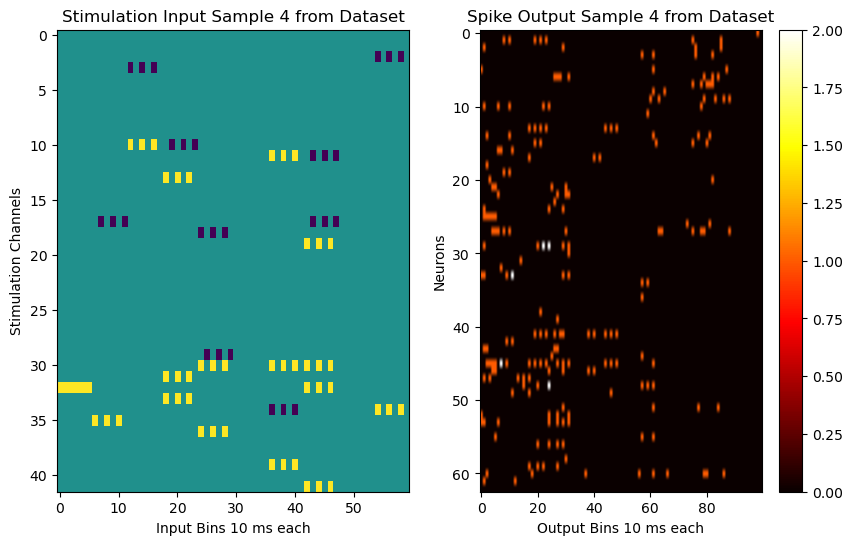

In [22]:
rand_idx = 4
if not train_dataset.init_state: 
    randx, randy = train_dataset[rand_idx]
else:
    randx, randy, rand_init = train_dataset[rand_idx]
time, t = train_dataset.samples[rand_idx]

pattern_name = train_dataset.timing_to_pattern[time]
# Extract input: stim bins [t, t + n_input_bins)
stim_full = train_dataset.pattern_stims[pattern_name]


# 1. Ensure randx is a tensor (if it's numpy, use torch.from_numpy)
target_slice = stim_full[:, 0 : 0 + train_dataset.n_input_bins]
stim_tensor = torch.as_tensor(target_slice, dtype=randx.dtype, device=randx.device)
# 2. Check for shape alignment
# Datasets often return (Time, Features) but stim_full might be (Features, Time)
if randx.shape != stim_tensor.shape:
    stim_tensor = stim_tensor.T 


# 3. Use a safe comparison with tolerances
# rtol=1e-05, atol=1e-08 are standard for float32

assert torch.allclose(randx, stim_tensor, atol=1e-7), \
    f"Shape mismatch! randx: {randx.shape}, slice: {stim_tensor.shape}"

print("Match confirmed! 🚀")
f, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(randx.cpu().numpy() if torch.is_tensor(randx) else randx, aspect='auto', cmap='viridis')
ax[0].set_xlabel(f"Input Bins {INPUT_BIN_SIZE_MS} ms each")
ax[0].set_ylabel("Stimulation Channels")
ax[0].set_title(f"Stimulation Input Sample {rand_idx} from Dataset")

im_spikes = ax[1].imshow(randy.cpu().numpy() if torch.is_tensor(randy) else randy, aspect='auto', cmap='hot')
ax[1].set_xlabel(f"Output Bins {OUTPUT_BIN_SIZE_MS} ms each")
ax[1].set_ylabel("Neurons")
ax[1].set_title(f"Spike Output Sample {rand_idx} from Dataset")
plt.colorbar(im_spikes)


## Sparsity Analysis of output bins

In [23]:
# plot_spike_bin_distribution(train_dataset, mode='counts', max_count=10, savepath=os.path.join(RUN_DIR, 'train_spike_distribution_counts.png'), logger=logger)

# sparsity_stats = train_dataset.compute_sparsity()
# mean_spikes = sparsity_stats['nonzero_bins'] / sparsity_stats['total_bins']


In [26]:
N_OUTPUT_BINS


100

In [24]:
# =====================
# Initialize Model
# =====================
# Extract model config from config file
MODEL_TYPE = cfg['model_type']
EMBEDDING_DIM = cfg['embedding_dim']
DROPOUT = cfg['dropout']
HIDDEN_DIMS = cfg['hidden_dims']
CONV_CHANNELS = cfg['conv_channels']
KERNEL_SIZES = cfg['kernel_sizes']
FC_DIMS = cfg['fc_dims']
INIT_BIAS = cfg['init_bias']
POOLING_CNN = cfg.get('pooling', "flatten")
LINEAR = cfg.get('linear', True)


if MODEL_TYPE == 'mlp':
    model = StimToSpikeMLP(
        n_stim_channels=n_stim_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        init_bias=INIT_BIAS,
        linear=LINEAR,
        num_stim_levels=NUM_STIM_LEVELS
    ).to(device)
elif MODEL_TYPE == 'cnn':
    model = SimpleCausalSpikeCNN(
        n_stim_channels=n_stim_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        conv_channels=CONV_CHANNELS,
        kernel_sizes=KERNEL_SIZES,
        fc_dims=FC_DIMS,
        dropout=DROPOUT,
        pooling=POOLING_CNN,
        num_stim_levels=NUM_STIM_LEVELS,
    ).to(device)
elif MODEL_TYPE == "rnn":
    LATENT_DIM = cfg.get('latent_dim', 128)
    N_INITIAL_STATE_BINS = cfg.get('n_initial_state_bins', 1)
    NUM_GRU_LAYERS = cfg.get('num_gru_layers', 1)
    model = SpikeRNN(
        n_stim_channels=n_stim_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        latent_dim=LATENT_DIM,
        n_initial_state_bins=N_INITIAL_STATE_BINS,
        num_stim_levels=NUM_STIM_LEVELS,
        num_gru_layers=NUM_GRU_LAYERS,
        dropout=DROPOUT,
        fc_dims=FC_DIMS,
    ).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Model: {MODEL_TYPE.upper()}")
logger.info(f"  Embedding: {NUM_STIM_LEVELS} categories -> {EMBEDDING_DIM}-dim vectors")
logger.info(f"  Hidden layers: {HIDDEN_DIMS if MODEL_TYPE == 'mlp' else CONV_CHANNELS}")
logger.info(f"  Dropout: {DROPOUT}")
logger.info(f"  Total parameters: {total_params:,}")
logger.info(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
batch = next(iter(train_loader))
if INIT_STATE:
    sample_x, sample_y, sample_init = batch
    sample_x, sample_init = sample_x.to(device), sample_init.to(device)
else:
    sample_x, sample_y = batch
    sample_x = sample_x.to(device)
    sample_init = None

with torch.no_grad():
    if INIT_STATE and hasattr(model, 'forward') and 'initial_spikes' in model.forward.__code__.co_varnames:
        sample_out = model(sample_x, initial_spikes=sample_init)
    else:
        sample_out = model(sample_x)

logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

assert sample_out.shape[1:] == sample_y.shape[1:], f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")


# Show some sample inputs
logger.info("Sample model inputs (first batch):")
neuron = 1
print (sample_x.shape)
# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, neuron, :].cpu().numpy()}")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {sample_out[i, neuron, :].cpu().numpy()}")

AssertionError: 

In [ ]:
# Import training functions from models.py
from models import train_epoch, validate

# =====================
# Extract Training Configuration
# =====================
NUM_EPOCHS = cfg['num_epochs']
LEARNING_RATE = cfg['learning_rate']
WEIGHT_DECAY = cfg['weight_decay']
WEIGHT_LOSS = cfg['weight_loss']
PATIENCE = cfg['patience']
CRITERION_FN = cfg['criterion_fn']
SUM_LOSS = cfg.get('sum_loss', False) # Use get() to provide default if missing

# Skip training if in inference mode
if not INFERENCE_MODE:
    # Loss function - Poisson NLL since spike responses are counts
    if CRITERION_FN == "poisson":
        criterion = nn.PoissonNLLLoss(log_input=True, reduction='none', full=True)
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([WEIGHT_LOSS], device=device))

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_corr': [],
        'lr': []
    }

    # Early stopping
    best_val_loss = float('inf')
    best_val_corr = -float('inf')
    val_corr = float(0)
    patience_counter = 0

    # Model save path
    model_save_path = os.path.join(RUN_DIR, 'best_stim_spike_model.pt')

    logger.info("Starting training...")
    logger.info("=" * 50)

    # Log training config
    train_config = {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'weight_loss': WEIGHT_LOSS,
        'criterion': CRITERION_FN,
        'patience': PATIENCE,
        'sum_loss': SUM_LOSS
    }
    with open(os.path.join(RUN_DIR, 'train_config.json'), 'w') as f:
        json.dump(train_config, f, indent=2)

    epoch_pbar = tqdm(range(NUM_EPOCHS), desc="Epochs")
    for epoch in epoch_pbar:
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, sum_loss=SUM_LOSS, grad_clip=False, weight_loss=WEIGHT_LOSS, use_init_state=USE_INIT_STATE)
        val_loss, val_corr = validate(model, val_loader, criterion, device, sum_loss=SUM_LOSS, weight_loss=WEIGHT_LOSS, use_init_state=USE_INIT_STATE)
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_corr'].append(val_corr)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Log progress
        epoch_pbar.set_postfix({
            'train_loss': f'{train_loss:.6f}',
            'val_loss': f'{val_loss:.6f}',
            'val_corr': f'{val_corr:.6f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        logger.info(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Val Corr: {val_corr:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping check
        if val_corr > best_val_corr:
            best_val_corr = val_corr
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), model_save_path)
            logger.info(f"Saved best model to {model_save_path}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                logger.info(f"Early stopping at epoch {epoch+1}")
                break

    logger.info("=" * 50)
    logger.info(f"Training complete! Best validation correlation: {best_val_corr:.6f}")

    # Save training history
    history_path = os.path.join(RUN_DIR, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    logger.info(f"Saved training history to {history_path}")
else:
    logger.info("Skipping training - Inference mode enabled")
    # Load training history from artifact path if available
    history_path = os.path.join(ARTIFACT_PATH, 'training_history.json')
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        logger.info(f"Loaded training history from {history_path}")
    else:
        history = None
        logger.warning(f"No training history found at {history_path}")

NameError: name 'INFERENCE_MODE' is not defined

Test Loss: 0.562451
Test corr:  0.336196
Test predictions shape: (7000, 63, 10)
Test targets shape: (7000, 63, 10)


2026-02-04 21:01:32,027 - INFO - Correlation between predicted and actual per-neuron averages: r=0.9954, p=5.41e-64


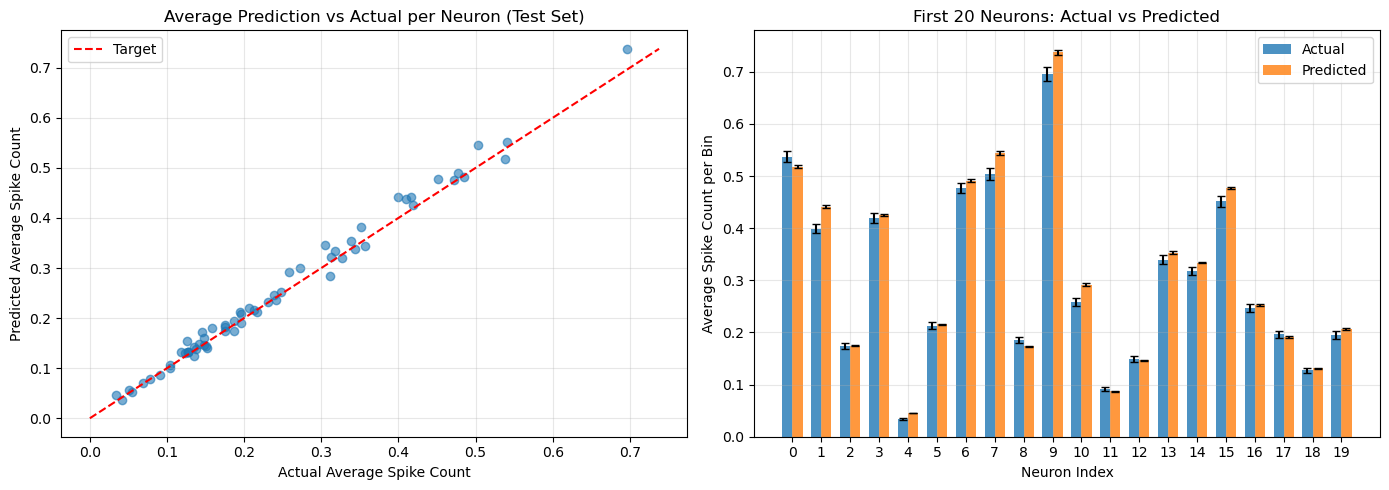

In [ ]:
import matplotlib.pyplot as plt
from viz import plot_test_prediction_comparison

# =====================
# Evaluate on Test Set
# =====================
# Load best model
model.load_state_dict(torch.load(os.path.join(RUN_DIR, 'best_stim_spike_model.pt')))

test_loss, test_corr = validate(model, test_loader, criterion, device, weight_loss=WEIGHT_LOSS, sum_loss=SUM_LOSS, use_init_state=USE_INIT_STATE)
print(f"Test Loss: {test_loss:.6f}")
print (f"Test corr: {test_corr: .6f}")

# Generate predictions on test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        if USE_INIT_STATE:
            batch_x, batch_y, batch_init = batch
            batch_x, batch_init = batch_x.to(device), batch_init.to(device)
            preds = model(batch_x, initial_spikes=batch_init)
        else:
            batch_x, batch_y = batch
            batch_x = batch_x.to(device)
            preds = model(batch_x)
        all_preds.append(preds.cpu())
        all_targets.append(batch_y)

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

print(f"Test predictions shape: {all_preds.shape}")
print(f"Test targets shape: {all_targets.shape}")

# =====================
# Visualize predictions aggregated by neuron
# =====================
fig, axes, corr, pval = plot_test_prediction_comparison(
    all_preds, all_targets, 
    savepath=os.path.join(RUN_DIR, 'test_prediction_comparison.png'),
    logger=logger
)
plt.show()

In [ ]:
from viz import analyze_pattern_responses_by_pattern_name

# Run the analysis on TEST set (oracle patterns)
pattern_names, pat_true, pat_pred, pat_counts = analyze_pattern_responses_by_pattern_name(model, test_dataset, device, use_init_state=USE_INIT_STATE)

# Summary statistics
logging.info(f"\nPer-pattern analysis:")
print(f"  Patterns: {len(pattern_names)}")
print(f"  True response range: [{pat_true.min():.4f}, {pat_true.max():.4f}]")
print(f"  Pred response range: [{pat_pred.min():.4f}, {pat_pred.max():.4f}]")

Found 50 unique oracle patterns in test set


2026-02-04 21:01:37,044 - INFO - 
Per-pattern analysis:


Samples per pattern: min=140, max=140, mean=140.0
  Patterns: 50
  True response range: [0.0000, 1.6321]
  Pred response range: [0.0288, 1.1000]


2026-02-04 21:01:47,430 - INFO - Pattern selectivity summary:
2026-02-04 21:01:47,431 - INFO -   Mean correlation across neurons: 0.4258
2026-02-04 21:01:47,432 - INFO -   Median correlation: 0.4066
2026-02-04 21:01:47,432 - INFO -   Neurons with r > 0.5: 19 / 63
2026-02-04 21:01:47,432 - INFO -   Neurons with r > 0.3: 51 / 63


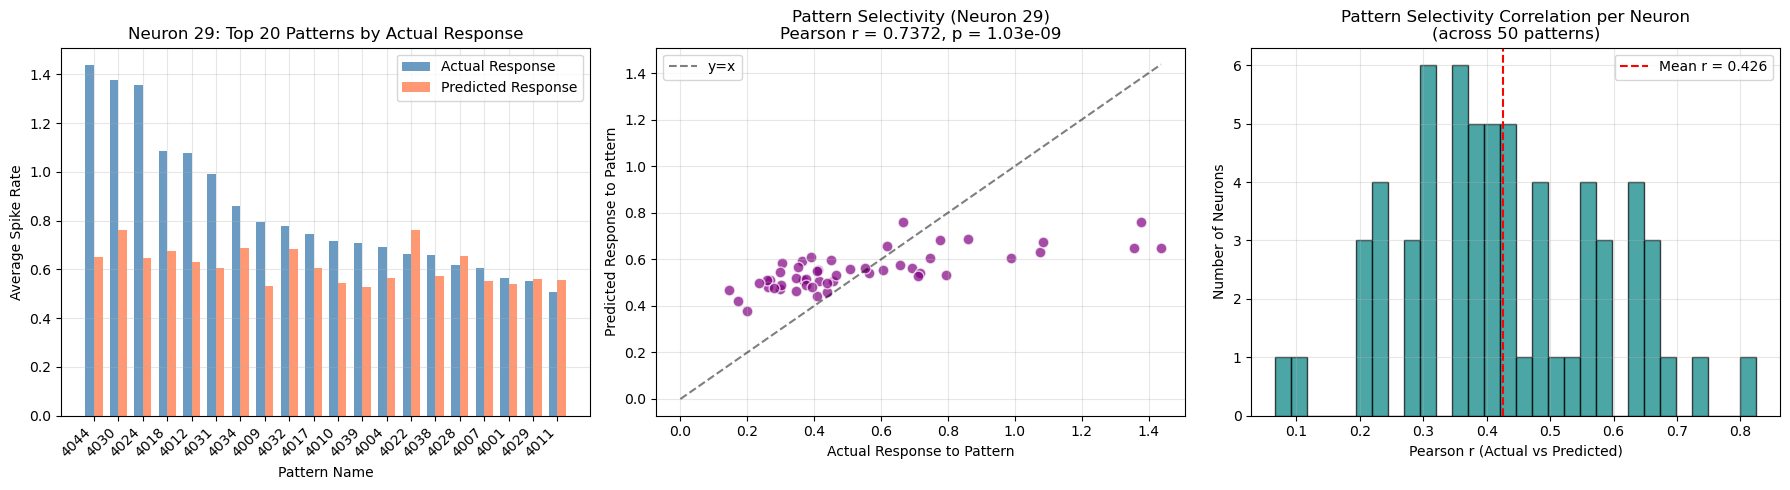

2026-02-04 21:01:47,585 - INFO - 
Pattern selectivity summary:
2026-02-04 21:01:47,586 - INFO -   Mean correlation across neurons: 0.4258
2026-02-04 21:01:47,586 - INFO -   Median correlation: 0.4066
2026-02-04 21:01:47,587 - INFO -   Neurons with r > 0.5: 19 / 63
2026-02-04 21:01:47,587 - INFO -   Neurons with r > 0.3: 51 / 63


In [ ]:
from viz import plot_pattern_selectivity

# =====================
# Visualization: Pattern Selectivity Analysis
# =====================
fig, axes, neuron_correlations = plot_pattern_selectivity(
    pattern_names, pat_true, pat_pred,
    savepath=os.path.join(RUN_DIR, 'pattern_selectivity_analysis.png'),
    logger=logger
)
plt.show()

# Print summary
logging.info(f"\nPattern selectivity summary:")
logging.info(f"  Mean correlation across neurons: {np.mean(neuron_correlations):.4f}")
logging.info(f"  Median correlation: {np.median(neuron_correlations):.4f}")
logging.info(f"  Neurons with r > 0.5: {(neuron_correlations > 0.5).sum()} / {len(neuron_correlations)}")
logging.info(f"  Neurons with r > 0.3: {(neuron_correlations > 0.3).sum()} / {len(neuron_correlations)}")

In [ ]:
# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
for i in range(min(1, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, 3, :].cpu().numpy()}")
for i in range(min(1, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {torch.exp(sample_out[i, 3, :]).cpu().numpy()}")



2026-02-04 21:01:54,160 - INFO - Sample model outputs (first batch):
2026-02-04 21:01:54,162 - INFO - Sample 0 target (neuron 4, all output bins): [0. 1. 0. 2. 3. 0. 0. 0. 0. 0.]
2026-02-04 21:01:54,166 - INFO - Sample 0 model output (neuron 4, all output bins): [1.0244478  0.9569247  1.0099366  0.9596999  0.9215493  0.96271116
 0.9494605  1.0104836  0.93529916 0.9536003 ]


In [ ]:
pattern_id = 4031
trial_idx = 1
chosen_pattern = pattern_df[(pattern_df['pattern_name'] == pattern_id) & (pattern_df['trial'] == trial_idx)]
max_time, min_time = chosen_pattern['pattern_end_timestamp'].max(), chosen_pattern['pattern_flag_start_timestamp'].min() # all values should be same anyways for these cols
spikes_during_pattern_trial= spikes_df[(spikes_df['timestamp'] <= max_time) & (spikes_df['timestamp'] >= min_time)]
print (min_time, max_time, max_time - min_time)
chosen_pattern

5439369 5500501 61132


,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial,pattern_end_timestamp,pattern_flag_start_timestamp,pattern_duration
1729,0,5439369,4031,1.0,74,10,NaN,NaN,True,1,5500501,5439369,61132
1730,1,5441169,4031,1.0,74,10,NaN,NaN,True,1,5500501,5439369,61132
1731,2,5442969,4031,1.0,74,10,20.0,-1.0,True,1,5500501,5439369,61132
1732,2,5442969,4031,1.0,74,10,37.0,0.0,True,1,5500501,5439369,61132
1733,3,5444891,4031,1.0,74,10,12.0,-1.0,True,1,5500501,5439369,61132
1734,3,5444891,4031,1.0,74,10,82.0,0.0,True,1,5500501,5439369,61132
1735,4,5446810,4031,1.0,74,10,20.0,0.0,True,1,5500501,5439369,61132
1736,4,5446810,4031,1.0,74,10,73.0,0.0,True,1,5500501,5439369,61132
1737,4,5446810,4031,1.0,74,10,56.0,0.0,True,1,5500501,5439369,61132
1738,4,5446810,4031,1.0,74,10,72.0,0.0,True,1,5500501,5439369,61132


In [ ]:
# Visualize spikes_during_pattern_trial: raster + binned at BIN_SIZE_MS
import numpy as np
import matplotlib.pyplot as plt
# Sort spikes for consistent plotting
trial_spikes = spikes_during_pattern_trial.sort_values(['neuron_id', 'timestamp'])

# Time relative to pattern start
t0 = min_time
times_rel = (trial_spikes['timestamp'].values - t0).astype(float)


# Time relative to pattern start
t0 = min_time
times_rel = (trial_spikes['timestamp'].values - t0).astype(float)
neurons_rel = trial_spikes['neuron_id'].values

# Build per-neuron spike time lists for raster
unique_neurons_trial = np.sort(trial_spikes['neuron_id'].unique())
spike_times_per_neuron = [times_rel[neurons_rel == nid] for nid in unique_neurons_trial]

# Binning across all neurons using BIN_SIZE_FRAMES
duration_frames = float(max_time - min_time)
print (duration_frames, " duration frames")
if duration_frames <= 0 or np.abs(duration_frames - 60000) >= 3000: # something is wrong
    raise ValueError("max_time must be grstimeater than min_time for binning.")

n_bins = int(np.ceil(duration_frames / BIN_SIZE_FRAMES))
# FIX: Use BIN_SIZE_FRAMES for the upper limit, not BIN_SIZE_MS
bin_edges = np.arange(0, (n_bins + 1) * BIN_SIZE_FRAMES, BIN_SIZE_FRAMES)
binned_counts, _ = np.histogram(times_rel, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# Per-neuron binned counts (same bins)
per_neuron_binned = []
for nid in unique_neurons_trial:
    neuron_times = times_rel[neurons_rel == nid]
    counts, _ = np.histogram(neuron_times, bins=bin_edges)
    per_neuron_binned.append(counts)
per_neuron_binned = np.stack(per_neuron_binned, axis=0)  # shape: (n_neurons_in_trial, n_bins)

fig, (ax_raster, ax_hist, ax_heat) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

# Raster plot (one row per neuron in this trial)
ax_raster.eventplot(
    spike_times_per_neuron,
    lineoffsets=np.arange(len(unique_neurons_trial)),
    linelengths=0.8,
    linewidths=0.5,
    color='black',
)
ax_raster.set_ylabel('Neuron (trial)')
ax_raster.set_title(f'Pattern {pattern_id}, trial {trial_idx}: spikes and {BIN_SIZE_MS} ms bins')
ax_raster.set_xlim(0, duration_frames)

# Binned spike counts (all neurons)
ax_hist.bar(
    bin_centers,
    binned_counts,
    width=BIN_SIZE_FRAMES * 0.9, # FIX: Width in frames
    align='center',
    color='gray',
    edgecolor='black',
)
ax_hist.set_ylabel('Spike count (all neurons)')
ax_hist.set_xlim(0, duration_frames)  # data recording is approx. variable 30 kHz

# Per-neuron bin counts heatmap
im = ax_heat.imshow(
    per_neuron_binned,
    aspect='auto',
    interpolation='nearest',
    extent=[0, n_bins * BIN_SIZE_FRAMES, len(unique_neurons_trial), 0], # FIX: Extent in frames
    cmap='viridis',
)
ax_heat.set_xlabel('Time from pattern start (frames)') # FIX: Label matches units
ax_heat.set_ylabel('Neuron (trial index)')
ax_heat.set_title(f'Per-neuron spike counts in {BIN_SIZE_MS} ms bins')
fig.colorbar(im, ax=ax_heat, label='Spike count')

plt.show()

NameError: name 'spikes_during_pattern_trial' is not defined

In [ ]:
# =====================
# Plot Training History and Test Results
# =====================
if history is not None and len(history.get('train_loss', [])) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[0].plot(np.arange(NUM_EPOCHS), [test_loss]*NUM_EPOCHS, label='Test Loss', color='red', linestyle="--")

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Log Loss)')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True)

    # Learning rate
    axes[1].plot(history['lr'], color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_yscale('log')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'training_history.png'), dpi=150)
    plt.show()
else:
    logger.warning("No training history available to plot")

NameError: name 'history' is not defined

In [ ]:
from viz import plot_oracle_trials_by_pattern

# Extract visualization config
PATTERN_LIMIT = cfg.get('pattern_limit', 50)

# Loop through oracle patterns and save per-pattern figures for trials 0-19
out_base = os.path.join(RUN_DIR, 'oracle_trials_by_pattern')

plot_oracle_trials_by_pattern(
    model=model,
    test_dataset=test_dataset,
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    pattern_polarities=pattern_polarities,
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    output_offset=OUTPUT_OFFSET,
    max_time_ms=1000,
    n_neurons=n_neurons,
    device=device,
    out_base=out_base,
    input_bin_size_ms=INPUT_BIN_SIZE_MS,
    logger=logger,
    pattern_limit=50,
    use_init_state=USE_INIT_STATE,
    n_initial_state_bins=N_INITIAL_STATE_BINS
)

2026-02-04 21:08:10,099 - INFO - Found 50 oracle patterns
2026-02-04 21:08:10,100 - INFO - Using input_bin_size=10ms, output_bin_size=60ms, n_input_bins=60, n_output_bins=10, output_offset=0
2026-02-04 21:08:10,101 - INFO - Total input bins: 100, Total output bins: 16
2026-02-04 21:08:10,101 - INFO - Valid input positions: 0 to 6
2026-02-04 21:08:10,482 - INFO - Saved pattern 4033 trial 0 figure to results/binned_2026-02-04_20-34-17/oracle_trials_by_pattern/pattern_4033/trial_00_timing_0.jpg
2026-02-04 21:08:17,850 - INFO - Completed pattern 4033 (1/50)
2026-02-04 21:08:18,211 - INFO - Saved pattern 4017 trial 0 figure to results/binned_2026-02-04_20-34-17/oracle_trials_by_pattern/pattern_4017/trial_00_timing_1.jpg
2026-02-04 21:08:24,733 - INFO - Completed pattern 4017 (2/50)
2026-02-04 21:08:25,047 - INFO - Saved pattern 4028 trial 0 figure to results/binned_2026-02-04_20-34-17/oracle_trials_by_pattern/pattern_4028/trial_00_timing_2.jpg
2026-02-04 21:08:31,112 - INFO - Completed patt

In [ ]:
# Test forward pass after training
batch = next(iter(train_loader))
if USE_INIT_STATE:
    sample_x, sample_y, sample_init = batch
    sample_x, sample_init = sample_x.to(device), sample_init.to(device)
else:
    sample_x, sample_y = batch
    sample_x = sample_x.to(device)
    sample_init = None

with torch.no_grad():
    if USE_INIT_STATE and hasattr(model, 'forward') and 'initial_spikes' in model.forward.__code__.co_varnames:
        sample_out = model(sample_x, initial_spikes=sample_init)
    else:
        sample_out = model(sample_x)

logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

assert sample_out.shape[1:] == sample_y.shape[1:], f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")

# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
neuron = 1
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, neuron, :].cpu().numpy()}")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {np.exp(sample_out[i, neuron, :].cpu().numpy())}")